# Session02: 大規模言語モデルの医学画像分析質問への対応精度評価

## Motivation（モチベーション）

この演習は、以下を学ぶことを目的としています：

- 医学画像に関する多肢選択問題を使って、モデルの実務的な性能を評価する方法を身につける。
- CSV データの前処理、集計、表・図の作成を通じて再現可能な解析ワークフローを学ぶ。
- 人間の受験者（student baseline）と LLM の結果を比較し、モデルの強み・弱みや分野依存性を理解する。
- コードを書き、可視化や統計指標の解釈を行うことで論文の Results および Materials and Methods セクションを構築する練習をする。


## 一般的な注意（単位・有効数字）

- 単位は原則として SI 単位で統一する（例: `mm`, `cm`, `mL`, `%`）。
- 数値と単位の間には半角スペースを入れる（例: `10 mm`）。ただし `%` は `76.0%` のように続けて表記する。
- 比較する値は同じ桁数で示し、有効数字をそろえる。
- 平均と標準偏差は桁数をそろえて記載する（例: `72.9% (SD = 9.3%)`）。
- 過度に細かい桁は避け、測定精度・解析目的に見合う桁数に丸める。

以下のノートブックは自分でコードを書きながら解析を進められるよう、実装のステップを記載しています。Google Colab用のリンクは後でスクリプトで差し替えてください。

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nakaura-T/DS_Seminar3_Public/blob/main/notebooks/session02_materials_and_results.ipynb)

## Colaboを開いた後の手順

data, imagesフォルダをそのままColaboのフォルダにコピーしてください。中身は手本の画像およびダミーデータです。自分で作成した表・図は、提出用として `./save_figures` フォルダに保存してください。保存するファイル名は `Table_1.png`, `Table_2.png`, `Figure_1.png`, `Figure_2.png` に統一します。

## 1) data の中身について (説明)

このノートブックでは、実際の 2024 年放射線診断学専門医試験の問題をもとに、LLM を API で呼び出して解かせた結果を、少し変更したダミーデータを扱います。データファイル: `markdowns/data/dummy_LLM.csv` を読み込んでください。

主なカラムは次の通りです:
- `Subspeciality`: 問題が属する医学専門分野 (例: Neuroradiology & Head & Neck)
- `Answer`: 正解ラベル (多肢選択の正解)
- `*_ans` カラム群: 各モデルが出力した候補回答 (例: `GPT-4.1_ans`)
- このCSVには正解/不正解の `0/1` 列は含めていません。`Answer` と各 `*_ans` を比較して、モデルごとの正解判定列（1=正解, 0=不正解）を自分で作成してください。

注意: 実データを用いるときは、`pd.read_csv` で読み込み、列名とデータ型を必ず確認してください。


In [73]:
# TODO: データ読み込みと前処理を実装してください
# 1) pandas を import する
# 2) CSV を読み込む（例: dummy_LLM.csv）
# 3) カラム名とデータ型を確認する
# 4) 欠損値・余分な空白を処理する
# 5) Answer と *_ans を比較して、各モデルの正解判定列（1/0）を作成する

import pandas as pd
import os

# 保存用ディレクトリの作成
os.makedirs('./save_figures', exist_ok=True)

# 2) CSV を読み込む
df = pd.read_csv('./data/dummy_LLM.csv')

# 3) カラム名とデータ型を確認する
print("--- Columns ---")
print(df.columns)
print("\n--- Dtypes ---")
print(df.dtypes)

# 4) 欠損値・余分な空白を処理する
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].str.strip()

# タイポ(fillma -> fillna)を修正し、ループの外（適切なインデント）へ移動
df = df.fillna("N/A")

# 5) Answer と *_ans を比較して、各モデルの正解判定列（1/0）を作成する
model_cols = [c for c in df.columns if c.endswith('_ans')]
for col in model_cols:
    # モデル名から '_ans' を削除
    model_name = col.replace('_ans', '')
    # 正解なら 1, 不正解なら 0 の整数型に変換
    df[model_name] = (df[col] == df['Answer']).astype(int)

print("\n--- 前処理完了 (最初の5行) ---")
display(df.head())

--- Columns ---
Index(['Subspeciality', 'Answer', 'GPT-4.1_ans', 'o3_ans',
       'Claude 3.7 Sonnet_ans', 'Claude 3.7 Sonnet-thinking_ans',
       'Gemini 2.5 Pro Preview_ans', 'Gemini 2.5 Flash Preview-thinking_ans'],
      dtype='object')

--- Dtypes ---
Subspeciality                            object
Answer                                   object
GPT-4.1_ans                              object
o3_ans                                   object
Claude 3.7 Sonnet_ans                    object
Claude 3.7 Sonnet-thinking_ans           object
Gemini 2.5 Pro Preview_ans               object
Gemini 2.5 Flash Preview-thinking_ans    object
dtype: object

--- 前処理完了 (最初の5行) ---


,Subspeciality,Answer,GPT-4.1_ans,o3_ans,Claude 3.7 Sonnet_ans,Claude 3.7 Sonnet-thinking_ans,Gemini 2.5 Pro Preview_ans,Gemini 2.5 Flash Preview-thinking_ans,GPT-4.1,o3,Claude 3.7 Sonnet,Claude 3.7 Sonnet-thinking,Gemini 2.5 Pro Preview,Gemini 2.5 Flash Preview-thinking
0,Neuroradiology & Head & Neck,d,d,a,a,a,a,a,1,0,0,0,0,0
1,Neuroradiology & Head & Neck,b,b,b,b,b,b,b,1,1,1,1,1,1
2,Neuroradiology & Head & Neck,a,c,c,c,c,c,c,0,0,0,0,0,0
3,Neuroradiology & Head & Neck,d,d,d,e,e,d,a,1,1,0,0,1,0
4,Neuroradiology & Head & Neck,e,e,e,e,e,c,e,1,1,1,1,0,1


## 2) 各分野の問題数を数えて Table をつくる

目標: 各 `Subspeciality` ごとの問題数を集計し、表（Table 1）を作成します。

次の手順を参考に進めてください。
- `df['Subspeciality'].value_counts()` で各分野の件数を取得します。
- 結果を `pd.DataFrame` に変換し、列名を `['Subspeciality', 'count']` のように整えます。
- 表を markdown に埋め込むには `df.to_markdown()` を使うか、表を画像として保存します。
- 作成した Table 1 は `./save_figures/Table_1.png` として保存します。
- ノートブック内で確認するときは、Table 1 のキャプションとともに `./save_figures/Table_1.png` を表示します。

--- Table 1: Number of Questions per Subspeciality ---


,Subspeciality,Count,percentage(%)
0,Abdominal & Pelvic,27,27.0
1,Thoracic & Cardiac,20,20.0
2,Nuclear Medicine,20,20.0
3,Neuroradiology & Head & Neck,16,16.0
4,MSK & Breast,11,11.0
5,Other,6,6.0


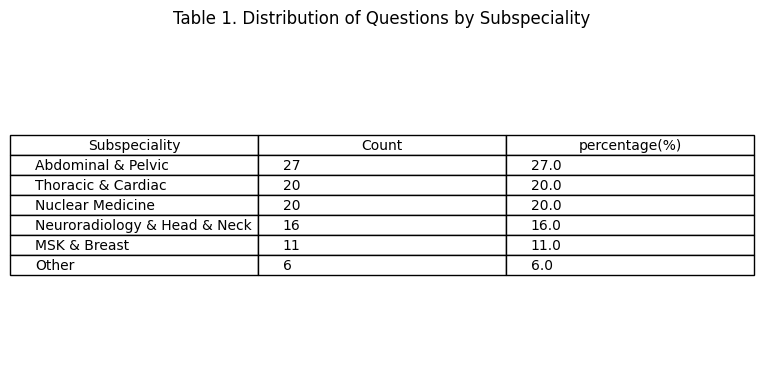

Table 1 saved to ./save_figures/Table_1.png


In [74]:
# TODO: Table 1（分野ごとの問題数）を作成して保存してください
import matplotlib.pyplot as plt

# 1) 分野ごとの件数を集計
table1 = df['Subspeciality'].value_counts().reset_index()
table1.columns = ['Subspeciality', 'Count']
table1['percentage(%)']=(table1['Count']/table1['Count'].sum()*100).round(1)
# 2) 表を表示
print("--- Table 1: Number of Questions per Subspeciality ---")
display(table1)

# 3) 表を画像として保存（matplotlibを使用）
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
table = ax.table(cellText=table1.values, colLabels=table1.columns, loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("Table 1. Distribution of Questions by Subspeciality", pad=20)
plt.savefig('./save_figures/Table_1.png', bbox_inches='tight', dpi=300)
plt.show()

print("Table 1 saved to ./save_figures/Table_1.png")

### Example: 質問数分布表の挿入例

以下は見本画像 `questions_table.png` を埋め込む例です。自分で作成した Table 1 は `./save_figures/Table_1.png` として保存してください。

![質問数分布表](https://github.com/Nakaura-T/DS_Seminar3_Public/blob/main/notebooks/images/questions_table.png?raw=1)

## 3) accuracy を求める

目標: 各モデルの正解率（accuracy）を定義し、全体と分野別に計算して Table 2 を作成します。

次の手順を参考に進めてください。
- まず `Answer` と各 `*_ans` を比較して、モデルごとの正解フラグ列（1=正解, 0=不正解）を作成します。
- 例: `GPT-4.1_ans` と `Answer` が一致したら `GPT-4.1=1`、不一致なら `0`。
- 正解フラグ列が作れたら、モデルごとの accuracy は `df[model].mean()` で求められます。
- パーセンテージ表示にする場合は `*100` を使います。
- 分野別 accuracy は `df.groupby('Subspeciality')[model].mean()` で求めます。
- 表の形式は、行をモデル、列を全体と各分野としたクロス表に整えます。
- 作成した Table 2 は `./save_figures/Table_2.png` として保存します。


--- Table 2: Accuracy (%) by Model and Subspeciality ---


Subspeciality,Overall,Abdominal & Pelvic,MSK & Breast,Neuroradiology & Head & Neck,Nuclear Medicine,Other,Thoracic & Cardiac
GPT-4.1,63.0%,51.9%,63.6%,68.8%,60.0%,66.7%,75.0%
o3,72.0%,77.8%,45.5%,68.8%,70.0%,83.3%,80.0%
Claude 3.7 Sonnet,59.0%,51.9%,63.6%,50.0%,50.0%,83.3%,75.0%
Claude 3.7 Sonnet-thinking,59.0%,51.9%,72.7%,43.8%,55.0%,100.0%,65.0%
Gemini 2.5 Pro Preview,74.0%,74.1%,63.6%,56.2%,75.0%,100.0%,85.0%
Gemini 2.5 Flash Preview-thinking,67.0%,63.0%,63.6%,43.8%,60.0%,100.0%,90.0%


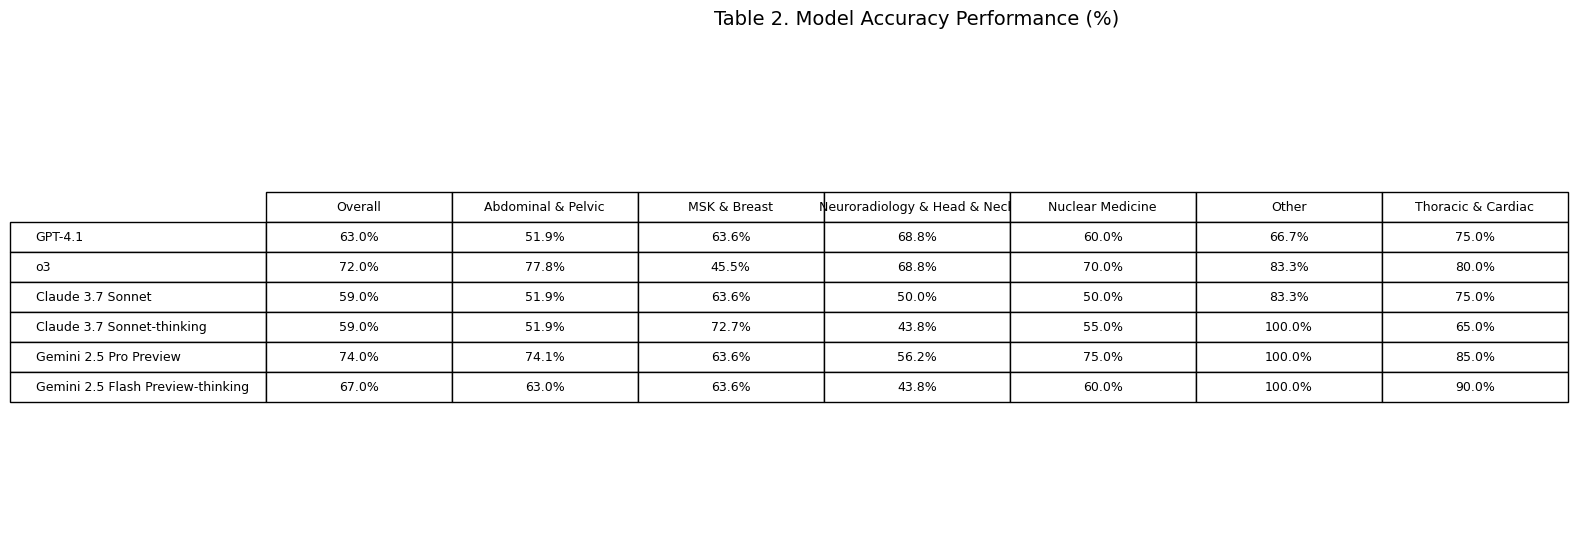

Table 2 saved to ./save_figures/Table_2.png


In [75]:
# TODO: Table 2（モデル別 accuracy）を作成して保存してください
import pandas as pd
import matplotlib.pyplot as plt

# 1) モデル名のリストを取得（前処理で作った 1/0 カラム）
models = [c.replace('_ans', '') for c in df.columns if c.endswith('_ans')]

# 2) 全体 accuracy を計算 (100倍してパーセント表示に)
overall_series = df[models].mean() * 100

# 3) Subspeciality ごとの accuracy を計算
field_acc = df.groupby('Subspeciality')[models].mean() * 100

# 4) 表の形式に整える（行：モデル、列：全体・各分野）
table2 = field_acc.T
table2.insert(0, 'Overall', overall_series)
table2 = table2.round(1)

# 表示用に '%' を付与したデータフレームを作成
table2_display = table2.astype(str) + "%"

print("--- Table 2: Accuracy (%) by Model and Subspeciality ---")
display(table2_display)

# 5) 表を画像として保存
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

# 数値に % を含めた状態でテーブル作成
table = ax.table(cellText=table2_display.values,
                 colLabels=table2_display.columns,
                 rowLabels=table2_display.index,
                 loc='center',
                 cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

plt.title("Table 2. Model Accuracy Performance (%)", pad=30, fontsize=14)
plt.savefig('./save_figures/Table_2.png', bbox_inches='tight', dpi=300)
plt.show()

print("Table 2 saved to ./save_figures/Table_2.png")

### Example: 精度テーブルの挿入例

以下は見本画像 `accuracy_table.png` を埋め込む例です。自分で作成した Table 2 は `./save_figures/Table_2.png` として保存してください。

![精度テーブル](https://github.com/Nakaura-T/DS_Seminar3_Public/blob/main/notebooks/images/accuracy_table.png?raw=1)

## 4) 受験生の平均、SD を求め、LLMの正解率と比較してプロットする

目標: 受験生（Human）がいると仮定した場合の平均得点と標準偏差を求め、それを LLM の精度と同じ図に重ねて比較します。

次の手順を参考に進めてください。
- 受験生データがあればその CSV を読み込み、各受験生の正答数を問題数で割って得点率を計算します。
- 受験生データがない場合は、`df['Answer']` を基準に多数決正答を human baseline として模擬する方法も考えられます。
- 平均と SD は `students_scores.mean()` / `students_scores.std()` で求めます。
- プロットでは、LLM のバープロットに `plt.axhline(student_mean, color='k', linestyle='--')` を重ね、必要に応じて `plt.fill_between(x, student_mean-student_sd, student_mean+student_sd, alpha=0.2)` を使います。
- 作成した Figure 1 は `./save_figures/Figure_1.png` として保存します。

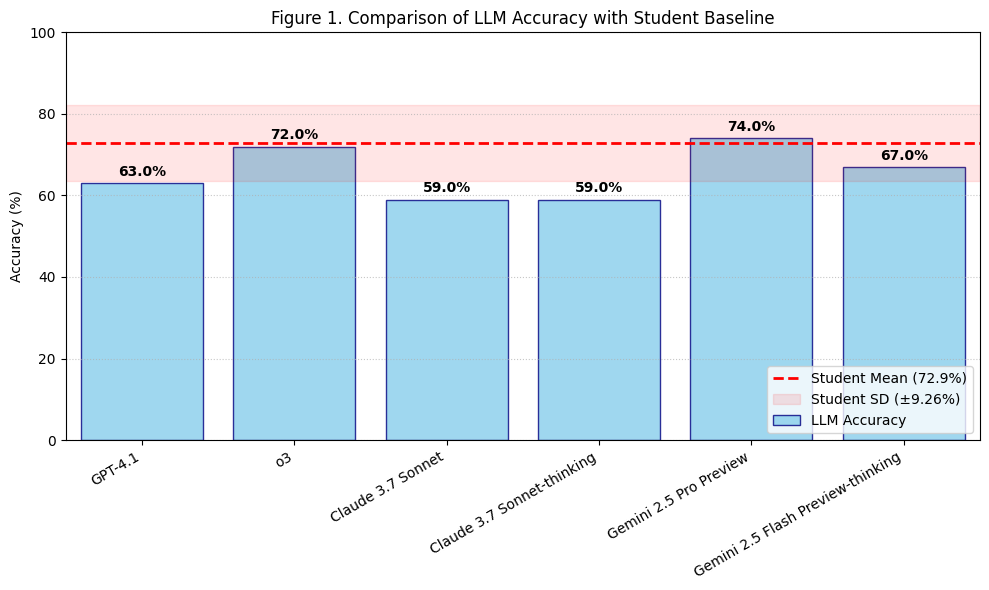

Figure 1 has been successfully regenerated as a bar chart.


In [76]:
import matplotlib.pyplot as plt
import numpy as np

# 1) データの準備
# 前のステップで計算した table2 から Overall の数値を取得
overall_acc = table2['Overall']
model_names = overall_acc.index

# 受験生データ (演習指示より: Mean=72.9, SD=9.26)
student_mean = 72.9
student_sd = 9.26

# 2) プロットの作成
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(model_names))

# LLMの正解率を棒グラフで表示
bars = ax.bar(x_pos, overall_acc, color='skyblue', alpha=0.8, edgecolor='navy', label='LLM Accuracy')

# 受験生平均を破線で表示
ax.axhline(student_mean, color='red', linestyle='--', linewidth=2, label=f'Student Mean ({student_mean}%)')

# 受験生SDの範囲を網掛けで表示
ax.fill_between([-0.5, len(model_names)-0.5],
                student_mean - student_sd,
                student_mean + student_sd,
                color='red', alpha=0.1, label=f'Student SD (±{student_sd}%)')

# 3) 装飾
ax.set_ylabel('Accuracy (%)')
ax.set_title('Figure 1. Comparison of LLM Accuracy with Student Baseline')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=30, ha='right')
ax.set_ylim(0, 100)
ax.set_xlim(-0.5, len(model_names)-0.5)
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.legend(loc='lower right')

# 棒グラフの上に数値を表示
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

# 4) 保存
plt.savefig('./save_figures/Figure_1.png', dpi=300)
plt.show()

print("Figure 1 has been successfully regenerated as a bar chart.")

### Example: 受験生平均とLLMの比較（挿入例）

以下は受験生平均や標準偏差をプロットした見本画像です。自分で作成した Figure 1 は `./save_figures/Figure_1.png` として保存してください。

![精度分布グラフ](https://github.com/Nakaura-T/DS_Seminar3_Public/blob/main/notebooks/images/model_performance_distribution.png?raw=1)

## 5) 各分野のLLM正解率をプロットしてレーダーチャートをつくる

目標: 各 `Subspeciality` ごとにモデルの正解率を集計し、モデルごとにレーダーチャートで比較します。

次の手順を参考に進めてください。
- `by_field = df.groupby('Subspeciality')[models].mean()` で分野別正答率を求めます。
- レーダーチャートでは各分野を角度にマッピングし、最後の点を先頭に追加してループを閉じます。
- matplotlib の `projection='polar'` を使って複数モデルを重ねて描画します。
- 軸のレンジを 0-100 (%) に揃えると見やすくなります。
- 作成した Figure 2 は `./save_figures/Figure_2.png` として保存します。

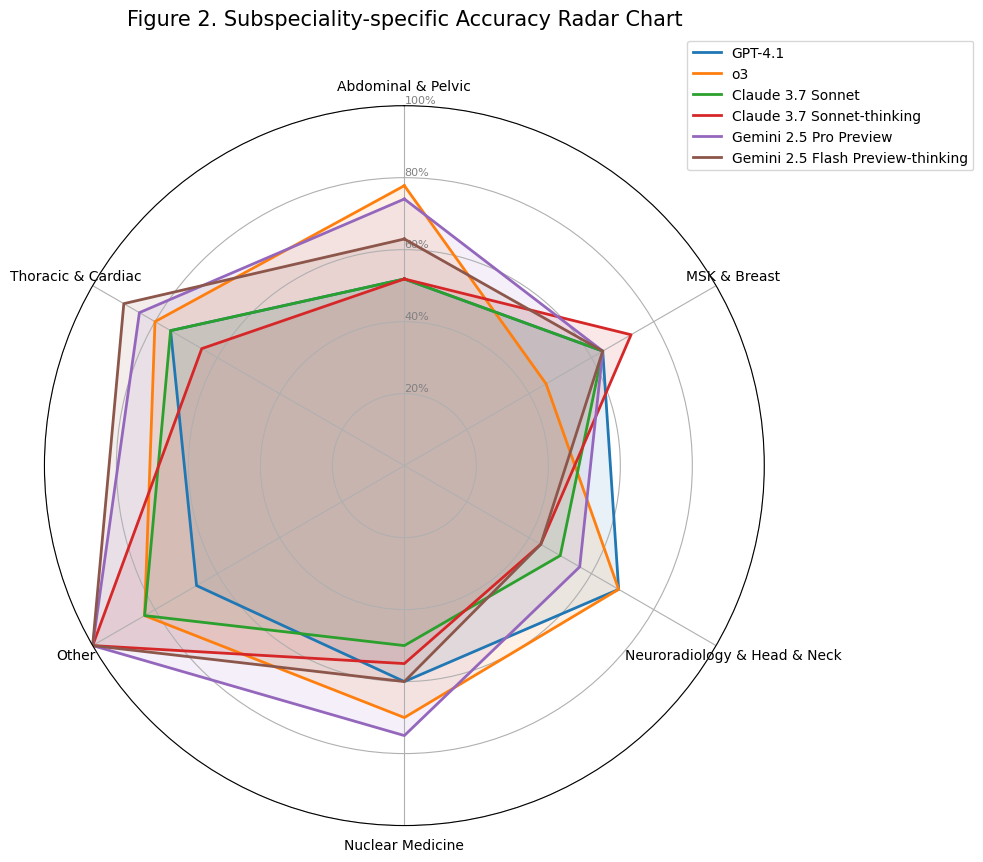

Figure 2 has been saved to ./save_figures/Figure_2.png


In [77]:
# TODO: 分野別 accuracy のレーダーチャート（Figure 2）を作成してください
import matplotlib.pyplot as plt
import numpy as np

# 1) データの準備
# groupby で各分野のモデル別平均を計算 (100倍して % に)
by_field = df.groupby('Subspeciality')[models].mean() * 100
categories = by_field.index.tolist()
N = len(categories)

# レーダーチャート用に角度を計算 (円を分割)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # ループを閉じるために最初に戻る

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# 2) 各モデルのデータをプロット
for model in models:
    values = by_field[model].values.flatten().tolist()
    values += values[:1]  # ループを閉じる
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=model)
    ax.fill(angles, values, alpha=0.1)

# 3) 装飾
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# 軸ラベルの設定
plt.xticks(angles[:-1], categories, size=10)

# 目盛りの設定
ax.set_rlabel_position(0)
plt.yticks([20, 40, 60, 80, 100], ["20%", "40%", "60%", "80%", "100%"], color="grey", size=8)
plt.ylim(0, 100)

plt.title("Figure 2. Subspeciality-specific Accuracy Radar Chart", size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# 4) 保存
plt.tight_layout()
plt.savefig('./save_figures/Figure_2.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 2 has been saved to ./save_figures/Figure_2.png")

### Example: レーダーチャートの挿入例

以下は分野ごとのモデル正解率を比較したレーダーチャートの見本画像です。自分で作成した Figure 2 は `./save_figures/Figure_2.png` として保存してください。

![レーダーチャート](https://github.com/Nakaura-T/DS_Seminar3_Public/blob/main/notebooks/images/radar_chart.png?raw=1)

## 6) Markdown で表・図へリンクする

この実習では、作成した表・図を `./save_figures` に保存し、論文ドラフトの Markdown からリンクします。Markdown では、画像を表示したい場所に次の形式で書きます。

```markdown
![表示名](画像ファイルへの相対パス)
```

このノートブックと同じ場所に `save_figures` フォルダがある場合、以下のように書きます。ファイル名には空白を使わず、`_` を使うと Pandoc で DOCX に変換するときも安全です。

```markdown
![Table 1](./save_figures/Table_1.png)
![Table 2](./save_figures/Table_2.png)
![Figure 1](./save_figures/Figure_1.png)
![Figure 2](./save_figures/Figure_2.png)
```

論文ドラフトでは、画像リンクの直前または直後に Table Legend / Figure Legend を書きます。例:

```markdown
Table 1. Distribution of radiology board examination questions by subspeciality.

![Table 1](./save_figures/Table_1.png)

Figure 1. Comparison of LLM accuracy with examinee performance.

![Figure 1](./save_figures/Figure_1.png)
```

注意: `./images` は見本画像を見るためのフォルダです。自分で作成した提出用の表・図は `./save_figures` からリンクしてください。

### Pandoc で DOCX に変換する

この実習では PDF ではなく DOCX に出力します。Pandoc で DOCX に変換する場合、LaTeX は不要です。Markdown ファイルと `save_figures` フォルダの位置関係が正しければ、画像は Word ファイル内に埋め込まれます。

```bash
pandoc paper.md -o paper.docx
```

Markdown ファイルが `notebooks` フォルダ内にあり、`notebooks/save_figures` を参照する場合は、次のような構成にしてください。

```text
notebooks/
├── paper.md
├── save_figures/
│   ├── Table_1.png
│   ├── Table_2.png
│   ├── Figure_1.png
│   └── Figure_2.png
```

本文中では、図表番号は手動で `Table 1`, `Table 2`, `Figure 1`, `Figure 2` と書いて参照します。

```markdown
The distribution of questions is shown in Table 1.

Table 1. Distribution of radiology board examination questions by subspeciality.

![Table 1](./save_figures/Table_1.png)
```

### 図表の自動参照について

`pandoc-crossref` を使うと `@fig:...` や `@tbl:...` のような自動参照も可能ですが、授業では環境差を避けるため使いません。まずは本文中に `Table 1` / `Figure 1` と手動で書く方法に統一します。

### DOCX での改ページ

DOCX では、改ページは変換後に Word で調整するのが簡単です。Markdown 内で改ページを指定したい場合は、Pandoc の DOCX 出力では OpenXML を使う方法があります。

```markdown
# Results
（本文）

~~~{=openxml}
<w:p><w:r><w:br w:type="page"/></w:r></w:p>
~~~

Table 1. Distribution of radiology board examination questions by subspeciality.

![Table 1](./save_figures/Table_1.png)
```

ただし、最初は改ページを入れずに DOCX を作成し、Word で最終調整する方が安全です。


## 7) Table Legend を書く

### Table Legend とは

Table Legend（表の説明文、caption）は、読者が本文を読まなくても「この表が何を示しているか」を理解できるようにする短い説明です。表そのものに書ききれない補足情報を整理して書きます。

Table Legend に含める内容:
- 表番号と短いタイトル: `Table 1. Distribution of questions by subspeciality.` のように書きます。
- 対象と単位: 何を数えた表か、`n`、`%`、accuracy などの単位を明記します。
- 略語の説明: LLM、SD など、表だけを見た読者に必要な略語を定義します。
- 計算方法の補足: accuracy を「正解数 / 問題数」として計算した、などを簡潔に書きます。

注意点:
- Legend は結果の解釈を長く述べる場所ではありません。
- 「どのモデルが最も優れていた」などの主張は Results 本文に書きます。
- 表中のすべての略語は、本文で説明済みでも legend 内で再度説明するのが基本です。


### Exercise 7-1: Table 1 の Legend を書く

Table 1 は、各 `Subspeciality` に含まれる問題数を示す表です。次の空欄を自分のデータに合わせて埋めてください。

```markdown
Table 1. Distribution of radiology board examination questions by subspeciality.

The table shows the number of questions included in each subspeciality category. Values are presented as counts and percentages of the total number of questions (n = ___).
```

自分で書く欄:

```markdown
Table 1. Distribution of radiology board examination questions by subspeciality.

The table shows the number of questions included in each subspeciality category. Values are presented as counts and percentages of the total number of questions (n = ___).
```


### Exercise 7-2: Table 2 の Legend を書く

Table 2 は、各 LLM の全体 accuracy と分野別 accuracy を示す表です。accuracy の定義、単位、略語を含めて書いてください。

```markdown
Table 2. Overall and subspeciality-specific accuracy of large language models.

Accuracy was calculated as the percentage of correctly answered questions. Rows indicate models, and columns indicate overall accuracy and accuracy for each subspeciality. LLM = large language model.
```

自分で書く欄:

```markdown
Table 2. Overall and subspeciality-specific accuracy of large language models.

Accuracy was calculated as the percentage of correctly answered questions. Rows indicate models, and columns indicate overall accuracy and accuracy for each subspeciality. LLM = large language model.
```


## 8) Figure Legend を書く

### Figure Legend とは

Figure Legend（図の説明文）は、図を見た読者が「何を比較しているのか」「軸や色が何を意味するのか」「エラーバーや線が何を示すのか」を理解できるようにする説明です。

Figure Legend に含める内容:
- 図番号と短いタイトル: `Figure 1. Comparison of model accuracy with student performance.` のように書きます。
- 図の内容: 何を、どのグループで、どの指標により比較したかを書きます。
- 軸・色・線・エラーバーの意味: `The dashed line indicates...` のように説明します。
- 略語の説明: LLM、SD などを定義します。

注意点:
- 図から読み取れる主要な傾向を少し書いてもよいですが、詳細な解釈は Results 本文に書きます。
- 図の legend は、読者が本文を読まなくても図を理解できる程度に具体的にします。


### Exercise 8-1: Figure 1 の Legend を書く

Figure 1 は、受験生平均と LLM の正解率を比較した図です。受験生の平均正解率と SD の具体的な数値、破線、帯など、自分の図で使った要素を説明してください。

```markdown
Figure 1. Comparison of LLM accuracy with student performance.

Bars show the overall accuracy of each LLM. The dashed horizontal line indicates the mean score of examinees (__%), and the shaded area indicates one standard deviation (SD, __%). LLM = large language model; SD = standard deviation.
```

自分で書く欄:

```markdown
Figure 1. Comparison of LLM accuracy with student performance.

Bars show the overall accuracy of each LLM. The dashed horizontal line indicates the mean score of examinees (__%), and the shaded area indicates one standard deviation (SD, __%). LLM = large language model; SD = standard deviation.
__________________________________________________________
```


### Exercise 8-2: Figure 2 の Legend を書く

Figure 2 は、分野別 accuracy をレーダーチャートで示した図です。各軸、線、塗りつぶし、単位を説明してください。

```markdown
Figure 2. Subspeciality-specific accuracy of LLMs.

The radar chart shows the accuracy of each LLM across subspeciality categories. Each axis represents one subspeciality, and values are shown as percentages. LLM = large language model.
```

自分で書く欄:

```markdown
Figure 2. Subspeciality-specific accuracy of LLMs.

The radar chart shows the accuracy of each LLM across subspeciality categories. Each axis represents one subspeciality, and values are shown as percentages. LLM = large language model.

```


## 9) Results を書く

### Results とは

Results は「データから何が得られたか」を客観的に書くセクションです。ここでは、方法の詳しい説明や、なぜその結果になったかという深い考察は書きません。それらは Materials and Methods や Discussion に分けます。

Results に書く内容:
- 解析に含まれたデータの要約: 最終的に解析に含まれた問題数、分野数、モデル数を短く確認します。詳しいデータの説明や選択基準は Materials and Methods に書きます。
- 表や図で示した主要な数値: 全体 accuracy、分野別 accuracy、受験生平均との比較など、読者に伝えるべき代表的な数値を書きます。
- データから直接言える傾向: どのモデルが高い/低い、どの分野で差が大きい、受験生平均と比べてどうだったかを書きます。
- 表・図への参照: 本文中で `Table 1`, `Table 2`, `Figure 1`, `Figure 2` を必ず引用します。

表や図を引用するときの考え方:
- `Table 1` は、解析に含まれた問題の分野別内訳を示すときに引用します。
- `Table 2` は、モデルごとの全体 accuracy や分野別 accuracy の数値を示すときに引用します。
- `Figure 1` は、LLM と受験生平均を視覚的に比較するときに引用します。
- `Figure 2` は、分野ごとの性能差やモデル間のパターンを説明するときに引用します。
- 本文では、表や図のすべての数値を繰り返すのではなく、最も重要な結果だけを選んで書きます。

避けること:
- 「なぜそうなったか」の推測を長く書く。
- 表や図の数値をすべて文章で繰り返す。
- Table や Figure を置くだけで、本文中で引用しない。
- 主観的な表現を使う。例: 「すごく良い」「かなり悪い」など。


# Results

A total of 100 radiology board examination questions across six subspecialties were included in this study. The distribution of questions was as follows: Abdominal & Pelvic (27.0%), Thoracic & Cardiac (20.0%), Nuclear Medicine (20.0%), Neuroradiology & Head & Neck (16.0%), MSK & Breast (11.0%), and Other (6.0%) (Table 1).

The overall accuracy varied among the six large language models (LLMs) evaluated (Table 2). Gemini 2.5 Pro Preview achieved the highest overall accuracy (74.0%), followed by o3 (72.0%). In contrast, Claude 3.7 Sonnet and its thinking variant showed the lowest overall accuracy at 59.0%.

Compared to the student baseline (mean 72.9% ± 9.3%), Gemini 2.5 Pro Preview (74.0%) and o3 (72.0%) performed at a level comparable to or slightly above the average student score. Other models, including GPT-4.1 (63.0%) and Gemini 2.5 Flash Preview-thinking (67.0%), fell below the student mean but remained within the distribution of student performance (Figure 1).

Subspeciality-specific performance showed significant variation across models (Table 2 and Figure 2). For instance, most models performed well in the "Other" and "Thoracic & Cardiac" categories, with Gemini 2.5 Pro Preview reaching 100% in both. However, accuracy was generally lower in "Neuroradiology & Head & Neck," where the highest score was only 56.3% (Gemini 2.5 Pro Preview).

## 10) Materials and Methods を書く

### Materials and Methods とは

Materials and Methods は「誰かが同じ解析を再現できるように、何を使って、どのように解析したか」を書くセクションです。Results とは異なり、ここでは結果の数値や解釈ではなく、手順と条件を明確に書きます。

まず、自然科学論文全般で一般に必要とされる要素を確認します。

- `Study design / Ethical considerations`:
  研究デザイン（実験・観察・シミュレーション等）、対象、倫理審査・同意・公開データ利用の扱い。
- `Materials / Data sources`:
  試料・機器・データの出所、選定基準、サンプル数、除外基準。
- `Procedures / Protocol`:
  実験手順・測定条件・前処理・品質管理（QC）・再現に必要な設定。
- `Outcome definitions`:
  何を主要評価項目としたか、変数や指標の定義（単位・計算式を含む）。
- `Statistical analysis`:
  使用した統計手法、仮説検定、信頼区間、有意水準、ソフトウェアとバージョン。
- `Reproducibility information`:
  コード・データ・乱数シード・実行環境など再現性に必要な情報。

このような一般指針は実在します。代表例として、医学系は EQUATOR Network（CONSORT, STROBE, PRISMA など）、生命科学は ARRIVE などの報告ガイドラインがあります。

この演習では、`MATERIALS AND METHODS` を以下の5項目で書いてください。

- `Ethical Considerations`
- `Data Collection`
- `Model Selection`
- `MLLM Interrogation and Data Processing`
- `Statistical Analysis`

各項目を書くために必要な情報を先に整理しておきます。

- `Ethical Considerations`:
  公開されている試験問題を使用し、人・動物対象研究は実施していないため倫理審査は不要。データは匿名化され、関連するプライバシー規制・ガイドラインに従って取り扱った。

- `Data Collection`:
  データセットは 2024 年 JRS（日本医学放射線学会）2次試験の多肢選択問題 100 問。内訳は画像あり 96 問（96%）、テキストのみ 4 問（4%）。問題は日本語で、6分野（Abdominal/Pelvic, Thoracic/Cardiac, Nuclear Medicine, Neuroradiology/Head&Neck, MSK/Breast, Other）をカバー。問題PDFは JRS 会員向けサイトから取得し、Adobe Acrobat でテキストと画像を抽出。画像は主要画像を PNG 300 DPI で分離。人間受験者成績は JRS への照会で取得し、平均 72.9%、SD 9.26%。

- `Model Selection`:
  2025年春時点の最新モデルとして 6 モデルを選定。選定原則は、(1) OpenAI/Anthropic/Google の主要フラッグシップを含めること、(2) アーキテクチャや派生（thinking variant）に多様性を持たせること。対象モデルは GPT-4.1, o3, Claude 3.7 Sonnet, Claude 3.7 Sonnet-thinking, Gemini 2.5 Pro Preview, Gemini 2.5 Flash Preview-thinking。

- `MLLM Interrogation and Data Processing`:
  OpenRouter API を Python 3.11.7 + openai ライブラリ 1.63.2 で自動実行。各設問は再試行なしで1回だけ問い合わせ、ステートレスに独立処理。画像問題（96問）は「画像あり」と「画像なし」の2条件で評価。画像は無加工で PNG を Base64 化し、API の image URL フィールドへ data URI 形式で送信。回答は説明文を含む場合があるため、手動確認して単一選択肢（a-e）に正規化し、正答判定に使用。回答拒否（画像が必要等）は不正解として扱った。

- `Statistical Analysis`:
  主要評価項目は accuracy（正答率）。採点は strict exact match（完全一致のみ正解、部分点なし）。各モデルについて全体 accuracy と分野別 accuracy を算出し、人間受験者平均と比較。画像あり/なしの比較は同一 96 問のペアデータに対して McNemar 検定を適用。有意水準は p < 0.05。統計解析は Python 3.11.7 と SciPy 1.13.1 で実施。

書き方のポイント:
- 過去形で書く（例: `Accuracy was calculated ...`）。
- 再現に必要な情報を優先する。
- 結果の良し悪しの解釈は Results に書き、Methods には書かない。


### Exercise 10: Materials and Methods のドラフトを書く

以下のヒントをもとに、自分の解析内容に合わせて Materials and Methods を英語で書いてください。ここでは英文の完成例は示しません。

書くときのヒント（推奨項目順）:
- `Ethical Considerations`: 公開データ利用であること、倫理審査要否、匿名化の扱いを書く。
- `Data Collection`: 使用した CSV、問題数、分野数、画像あり/なしの内訳、主要カラムを書く。
- `Model Selection`: 評価したモデル名、比較対象（student baseline）の扱い、選定理由を書く。
- `MLLM Interrogation and Data Processing`: 実行環境、前処理、プロンプト条件、回答整形ルール、保存先を簡潔に書く。
- `Statistical Analysis`: accuracy の定義、全体/分野別の計算、student baseline の平均・SD、必要なら検定法と有意水準を書く。
- Methods では結果の数値や「どのモデルが良かったか」という解釈は書かない。

自分で書く欄:

```markdown
# Materials and Methods

## Ethical Considerations
__________________________________________________________
__________________________________________________________
__________________________________________________________

## Data Collection
__________________________________________________________
__________________________________________________________
__________________________________________________________

## Model Selection
__________________________________________________________
__________________________________________________________
__________________________________________________________

## MLLM Interrogation and Data Processing
__________________________________________________________
__________________________________________________________
__________________________________________________________

## Statistical Analysis
__________________________________________________________
__________________________________________________________
__________________________________________________________
```


## 11) チェックリスト

以下を確認してください。

- Table 1 と Table 2 に、それぞれ Table Legend がある。
- Table 1、Table 2、Figure 1、Figure 2 が `./save_figures` に保存されている。
- 論文ドラフトの Markdown で、`./save_figures/Table_1.png` などの相対パスを使って自分の表・図にリンクしている。
- Figure 1 と Figure 2 に、それぞれ Figure Legend がある。
- すべての legend で略語を説明している。
- Results では、Table 1、Table 2、Figure 1、Figure 2 を本文中で参照している。
- Results には主要な数値が入っている。
- Materials and Methods には、データ、前処理、accuracy の定義、分野別解析、可視化方法が書かれている。
- Results に方法の詳細を書きすぎていない。
- Materials and Methods に結果の解釈を書いていない。
- Materials and Methods と Results を `paper.md` にまとめて保存している。
- `pandoc` で `paper.docx` を作成し、Word で内容と画像の表示を確認している。


## 12) `paper.md` を保存して DOCX を作成する

最後に、今回作成した `Materials and Methods` と `Results` を 1 つの Markdown ファイルにまとめ、DOCX を作成します。

手順:
1. ノートブック内で書いた `Materials and Methods` と `Results` を `paper.md` として保存する（章の順番は `Materials and Methods` → `Results`）。
2. 表・図の相対パス（例: `./save_figures/Table_1.png`）が正しいことを確認する。
3. ターミナルで次を実行して DOCX を作成する。
4. 作成した `paper.docx` を Word で開き、表・図が表示されていることを確認する。

```bash
pandoc paper.md -o paper.docx
```

`paper.md` と `save_figures` は、次のような位置関係にしてください。

```text
notebooks/
├── paper.md
├── paper.docx
└── save_figures/
    ├── Table_1.png
    ├── Table_2.png
    ├── Figure_1.png
    └── Figure_2.png
```

`paper.md` の例:

```markdown
# Materials and Methods

## Ethical Considerations
（今回作成した文章）

## Data Collection
（今回作成した文章）

## Model Selection
（今回作成した文章）

## MLLM Interrogation and Data Processing
（今回作成した文章）

## Statistical Analysis
（今回作成した文章）

# Results

（今回作成した文章）

**Table 1. Distribution of questions by subspecialty**

![Table 1](./save_figures/Table_1.png)

**Table 2. Model accuracy (overall and by subspecialty)**

![Table 2](./save_figures/Table_2.png)

**Figure 1. Comparison between examinee baseline and model accuracy**

![Figure 1](./save_figures/Figure_1.png)

**Figure 2. Subspecialty-wise model performance (radar chart)**

![Figure 2](./save_figures/Figure_2.png)
```

DOCX では、改ページや細かいレイアウトは変換後に Word で調整するのが簡単です。Markdown 側ではまず、見出し、本文、Table/Figure legend、画像リンクが正しく並んでいることを優先してください。
